In [1]:
import re
import pandas as pd
from collections import Counter
from clean_text import *
from adjustText import adjust_text 

import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/lingyaoli/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lingyaoli/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lingyaoli/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lingyaoli/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lingyaoli/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lingyaoli/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lingyaoli/nltk_data...
[nltk_data]   Package ave

True

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib import rcParams

rcParams['figure.dpi'] = 500
rcParams['savefig.dpi'] = 500
rcParams['font.family'] = 'Arial'
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 16

mmi = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']

# Define MMI color map globally for consistent access
mmi_colors = {
    'I': '#B9D3F6',    # Light blue
    'II': '#9FC5F4',
    'III': '#86B7F2',  # Blue
    'IV': '#70E7F7',   # Cyan
    'V': '#92E285',    # Green
    'VI': '#FFFF00',   # Yellow
    'VII': '#FFC800',  # Orange
    'VIII': '#FF9100', # Dark orange
    'IX': '#FF0000',   # Red
    'X': '#C80000',    # Dark red
    'XI': '#A00000',   # Darker red
    'XII': '#800000',   # Very dark red
    'DEFAULT': '#CCCCCC'
}

In [3]:
keywords = {
    'location': ['location', 'distance'],
    'geospatial': ['vs30', 'soil', 'site condition'],
    'building': ['building', 'structure'],
    'socioeconomic': ['population', 'density', 'income', 'education', 'elderly'],
    'visual': ['visual', 'image', 'streetview']
}

def categorize_reasoning(text, keywords):
    sentences = re.split(r'(?<=[^\d\W])\.\s+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    categories = {key: [] for key in keywords}
    vs30_index = -1
    socioecon_index = len(sentences)

    for i, sentence in enumerate(sentences):
        lower_sentence = sentence.lower()
        if vs30_index == -1 and any(kw in lower_sentence for kw in keywords['geospatial']):
            vs30_index = i
        if socioecon_index == len(sentences) and any(kw in lower_sentence for kw in keywords['socioeconomic']):
            socioecon_index = i

    for i, sentence in enumerate(sentences):
        lower_sentence = sentence.lower()
        if any(kw in lower_sentence for kw in keywords['socioeconomic']):
            categories['socioeconomic'].append(sentence)
            continue
        if any(kw in lower_sentence for kw in keywords['visual']):
            categories['visual'].append(sentence)
            continue
        if vs30_index < i < socioecon_index:
            if any(kw in lower_sentence for kw in keywords['building']):
                categories['building'].append(sentence)
                continue  
        if any(kw in lower_sentence for kw in keywords['geospatial']):
            categories['geospatial'].append(sentence)
        elif any(kw in lower_sentence for kw in keywords['location']):
            categories['location'].append(sentence)

    return {cat: ' '.join(parts) for cat, parts in categories.items()}

In [4]:
def process_data(filepath):
    df = pd.read_json(filepath)
    df['clean_reasoning'] = df['reasoning'].apply(clean_text)
    categorized_df = df["reasoning"].apply(lambda x: categorize_reasoning(x, keywords)).apply(pd.Series)
    final_df = pd.concat([df, categorized_df], axis=1)
    final_df['socioeconomic_clean'] = final_df['socioeconomic'].apply(clean_text)
    final_df['building_clean'] = final_df['building'].apply(clean_text)
    final_df['visual_clean'] = final_df['visual'].apply(clean_text)
    return final_df

df1 = process_data('result_zipcode/2019_ridgecrest_B+G+B+C+V_gpt-4.1-mini-2025-04-14.json')
df2 = process_data('result_zipcode/2014_napa_B+G+B+C+V_Qwen2.5-VL-32B-Instruct.json')

/Users/lingyaoli/Desktop/Project-LLM-Disaster/result-analysis/clean_text.py:42: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()
/Users/lingyaoli/Desktop/Project-LLM-Disaster/result-analysis/clean_text.py:42: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()
/Users/lingyaoli/Desktop/Project-LLM-Disaster/result-analysis/clean_text.py:42: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()
/Users/lingyaoli/Desktop/Project-LLM-Disaster/result-analysis/clean_text.py:42: MarkupResemblesLocatorWarning: The input loo

In [5]:
df1 = df1[df1['MMI_predicted'].isin(mmi)]
df2 = df2[df2['MMI_predicted'].isin(mmi)]
print(len(df1), len(df2))

4997 4574


In [6]:
def plot_distinctive_mmi_ngrams(
    df: pd.DataFrame,
    mmi_c: str = 'MMI_predicted',
    txt_c: str = 'clean_reasoning',
    top_n: int = 10,
    top_n_mmi: int = 5,
    font_size: int = 10,
    mode: str = 'unigram',  # or 'bigram'
    ax=None,
    add_title: bool = True,
    adjust_text_params: dict = None,
    remove_words: list = None 
):
    """
    Updated function allowing removal of specified words from plots.
    """

    remove_words = set(remove_words) if remove_words else set()

    if top_n_mmi is not None and top_n_mmi > 0:
        mmi_counts = df[mmi_c].value_counts()
        actual_top_n_mmi = min(top_n_mmi, len(mmi_counts))
        top_mmi_values = mmi_counts.nlargest(actual_top_n_mmi).index.tolist()
        df_filtered = df[df[mmi_c].isin(top_mmi_values)].copy()
    else:
        df_filtered = df.copy()

    if df_filtered.empty:
        print("No data to plot.")
        return None

    rom_map = {'I':1, 'II':2, 'III':3, 'IV':4, 'V':5, 'VI':6, 'VII':7, 'VIII':8, 'IX':9, 'X':10, 'XI':11, 'XII':12}
    mmi_sorted = sorted(df_filtered[mmi_c].unique(), key=lambda x: rom_map.get(str(x).upper(), float('inf')))

    MIN_WORD_LENGTH = 4
    mmi_texts = {}

    for mmi_val in mmi_sorted:
        subset = df_filtered[df_filtered[mmi_c] == mmi_val]
        raw_text = " ".join(subset[txt_c].astype(str))
        tokens = word_tokenize(raw_text.lower())

        if mode == 'unigram':
            tokens = [token for token in tokens if len(token) >= MIN_WORD_LENGTH and token not in remove_words]
            mmi_texts[mmi_val] = " ".join(tokens)
        else:
            tokens = [token for token in tokens if len(token) >= MIN_WORD_LENGTH and token not in remove_words]
            bigrams_list = list(ngrams(tokens, 2))
            bigram_text = " ".join(["_".join(bg) for bg in bigrams_list])
            mmi_texts[mmi_val] = bigram_text

    corpus = [mmi_texts[mmi] for mmi in mmi_sorted]
    mmi_labels = list(mmi_sorted)

    tfidf_vectorizer = TfidfVectorizer(max_features=2000, min_df=1, max_df=0.8)
    tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    data_points = []

    for i, mmi in enumerate(mmi_labels):
        tfidf_scores = tfidf_matrix[i].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-top_n:][::-1]

        for idx in top_indices:
            term = feature_names[idx]
            if term in remove_words:
                continue
            score = tfidf_scores[idx]

            if mode == 'bigram' and '_' in term:
                term = term.replace('_', ' ')

            if score > 0:
                data_points.append({
                    'MMI': mmi,
                    'Text': term,
                    'Score': score,
                    'LogScore': np.log1p(score)
                })

    if not data_points:
        print("No distinctive n-grams found after removing custom words.")
        return None

    plot_df = pd.DataFrame(data_points)
    plot_df['MMI'] = pd.Categorical(plot_df['MMI'], categories=mmi_sorted, ordered=True)
    plot_df = plot_df.sort_values(by=['MMI', 'Score'], ascending=[True, False])

    if ax is None:
        fig_height = max(8, len(mmi_sorted) * 1.8)
        fig, ax = plt.subplots(figsize=(8, fig_height))

    for mmi_val_iter in mmi_sorted:
        subset = plot_df[plot_df['MMI'] == mmi_val_iter]
        if subset.empty:
            continue
        color = mmi_colors.get(str(mmi_val_iter), '#CCCCCC')
        sns.stripplot(data=subset, x='LogScore', y='MMI', s=10, alpha=0.7, jitter=0.1, color=color, ax=ax, order=mmi_sorted)

    texts = []
    for _, row in plot_df.iterrows():
        mmi_idx = mmi_sorted.index(row['MMI'])
        text_obj = ax.text(row['LogScore'], mmi_idx, row['Text'],
                           fontsize=font_size, color='black',
                           horizontalalignment='center', verticalalignment='center')
        texts.append(text_obj)

    default_adjust_params = {'arrowprops': dict(arrowstyle='-', color='darkgray', lw=0.5, alpha=0.6), 'expand_points': (1.2, 1.2), 'expand_text': (1.4, 1.6), 'force_text': (0.5, 0.7), 'force_points': (0.1, 0.2), 'ha': 'center', 'va': 'center', 'only_move': {'points':'y', 'text':'xy'}, 'lim': 500}

    current_adjust_params = default_adjust_params.copy()
    if adjust_text_params:
        current_adjust_params.update(adjust_text_params)

    if texts:
        adjust_text(texts, ax=ax, **current_adjust_params)

    ax.set_yticklabels(mmi_sorted)
    ax.set_xlabel(f"Log(TF-IDF) ({'Bigrams' if mode=='bigram' else 'Unigrams'})")

    if add_title:
        ax.set_ylabel("MMI Level")
        ax.set_title(f"{txt_c.split('_')[0]}")
    else:
        ax.set_ylabel("")

    ax.grid(axis='x', linestyle='--', alpha=0.6)

    return plot_df


In [11]:
def plot_all_sources(
    df: pd.DataFrame,
    sources: list = ['building_clean', 'socioeconomic_clean', 'visual_clean'],
    mmi_c: str = 'MMI_predicted',
    top_n: int = 15,
    top_n_mmi: int = 5,
    font_size: int = 10,
    mode: str = 'unigram',
    figsize: tuple = (16, 5), 
    custom_words: list=None,
    adjust_text_params_override: dict = None 
):
    """
    Create a single figure with three plots side by side, one for each data source,
    and a common legend for the MMI levels.
    """
    num_sources = len(sources)
    fig, axes = plt.subplots(1, num_sources, figsize=figsize, sharey=True)
    if num_sources == 1: # Ensure axes is always a list-like object
        axes = [axes]

    results = []
    
    source_specific_base_params = [
        { # Source 1 (building_clean)
            'expand_text': (1.4, 1.7), 
            'force_text': (0.6, 0.8),
            'arrowprops': dict(arrowstyle='-', color='gray', lw=0.4, alpha=0.5)
        },
        { # Source 2 (socioeconomic_clean)
            'expand_text': (1.5, 1.8),
            'force_text': (0.7, 0.9),
            'arrowprops': dict(arrowstyle='-', color='gray', lw=0.4, alpha=0.5)
        },
        { # Source 3 (visual_clean)
            'expand_points': (1.3, 1.3), 
            'expand_text': (1.8, 2.2),
            'force_text': (0.9, 1.2),    
            'force_points': (0.3, 0.5), 
            'arrowprops': dict(arrowstyle='-', color='lightgray', lw=0.3, alpha=0.35)
        }
    ]

    for i, source in enumerate(sources):
        add_y_label_and_title = (i == 0)

        # Determine the text adjustment parameters for the current source
        current_plot_adjust_params = {}
        if adjust_text_params_override: # If a global override is provided
             current_plot_adjust_params = adjust_text_params_override
        elif i < len(source_specific_base_params):
            current_plot_adjust_params = source_specific_base_params[i]

        plot_df = plot_distinctive_mmi_ngrams(
            df=df,
            mmi_c=mmi_c,
            txt_c=source,
            top_n=top_n,
            top_n_mmi=top_n_mmi,
            font_size=font_size,
            mode=mode,
            ax=axes[i],
            add_title=True, 
            remove_words=custom_words,
            adjust_text_params=current_plot_adjust_params 
        )
        if i > 0:
            axes[i].set_ylabel("")

        results.append(plot_df)

    # Create legend items for all MMI levels
    all_mmi_levels = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']
    legend_elements = []

    for level in all_mmi_levels:
        color = mmi_colors.get(level, '#CCCCCC')
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                  markersize=10, label=f'MMI {level}')
        )

    fig.legend(
        handles=legend_elements,
        title="MMI Intensity Scale",
        loc='upper center',
        bbox_to_anchor=(0.5, 0.08),
        ncol=6 
    )

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.2, top=0.88 if fig._suptitle else 0.92)

    return fig, axes, results

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3801304885.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3801304885.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3801304885.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)


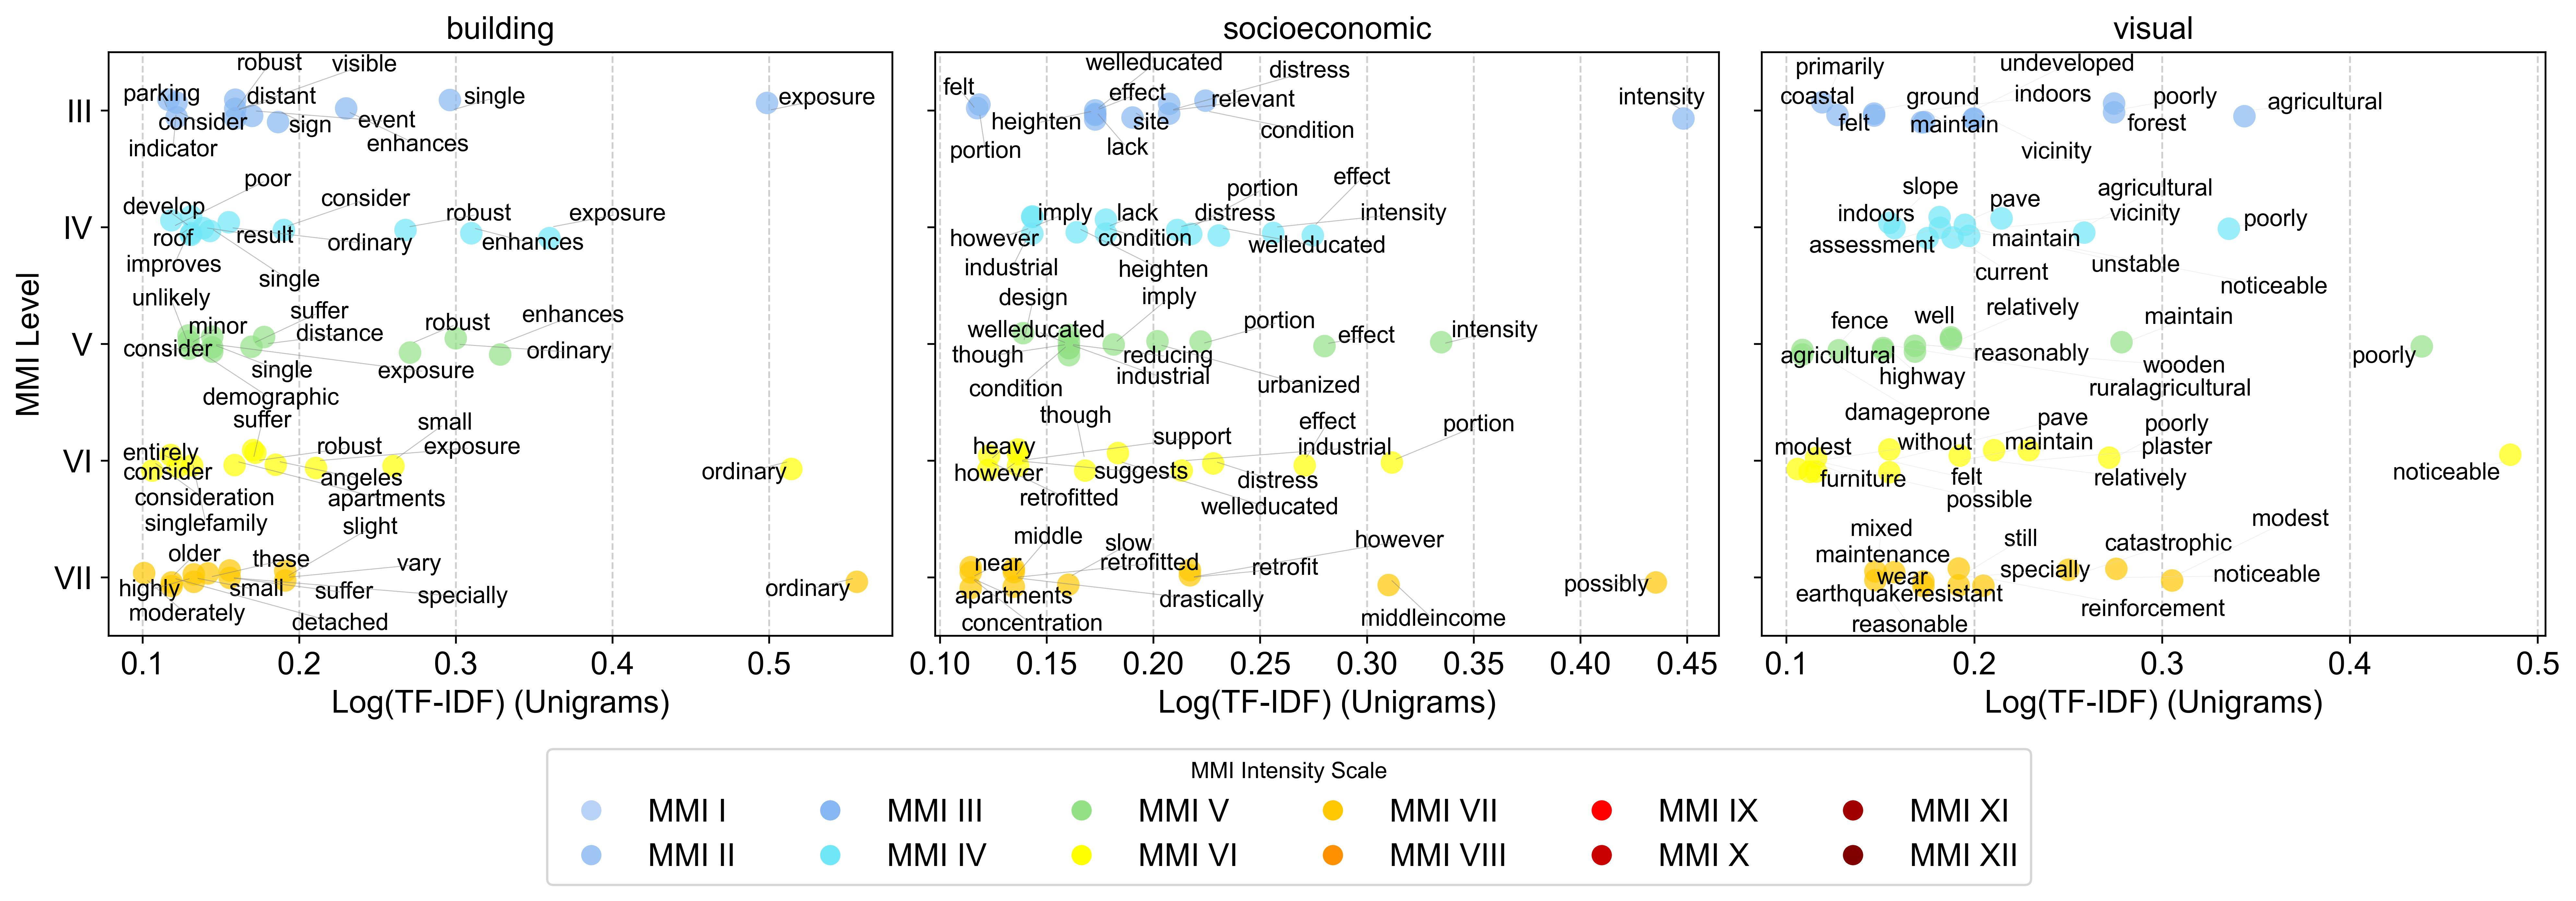

In [12]:
custom_words = ['specific', 'ageles', 'los', 'ridgecrest', 'adherence', 'hospital', 'warehouse', 'specific', 'green', 'rather',]

fig, axes, plot_dfs = plot_all_sources(
    df1,
    sources=['building_clean', 'socioeconomic_clean', 'visual_clean'],
    mmi_c='MMI_predicted',
    top_n=11, 
    top_n_mmi=5, 
    font_size=10.5,
    mode='unigram',
    custom_words = custom_words
)
plt.show()

/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3801304885.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3801304885.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3801304885.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)


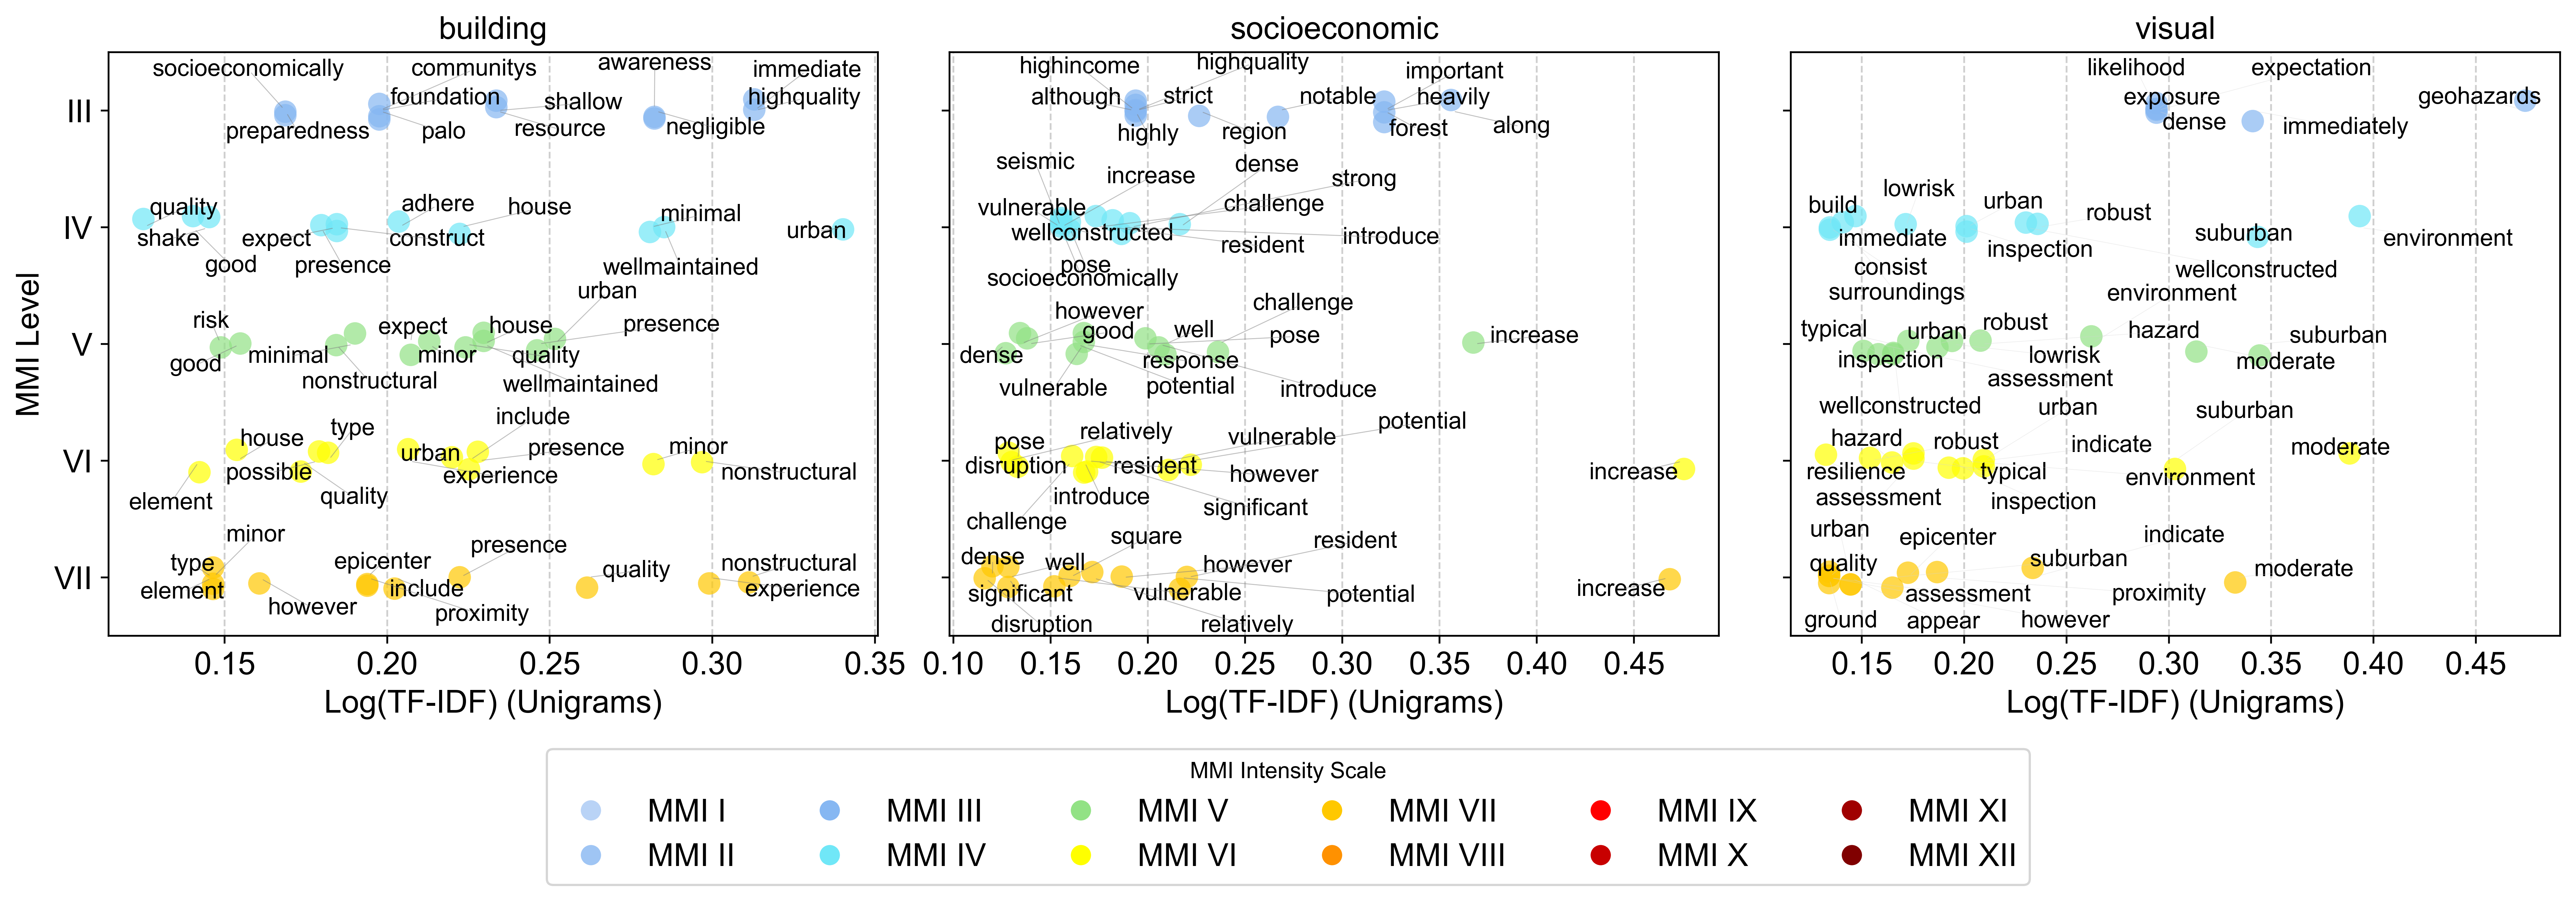

In [13]:
custom_words = ['specific', 'ageles', 'los', 'ridgecrest', 'adherence', 'meter', 'alto', 'still',
                'hospital', 'warehouse', 'specific', 'green', 'rather', 'this', 'california']

fig, axes, plot_dfs = plot_all_sources(
    df2,
    sources=['building_clean', 'socioeconomic_clean', 'visual_clean'],
    mmi_c='MMI_predicted',
    top_n=11, 
    top_n_mmi=5, 
    font_size=10.5,
    mode='unigram',
    custom_words = custom_words
)
plt.show()

/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3669068420.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3669068420.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3669068420.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3brd6kd23d1j64rj2yz5r100000gp/T/ipykernel_11338/3669068420.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mmi_sorted)
/var/folders/l0/f3br

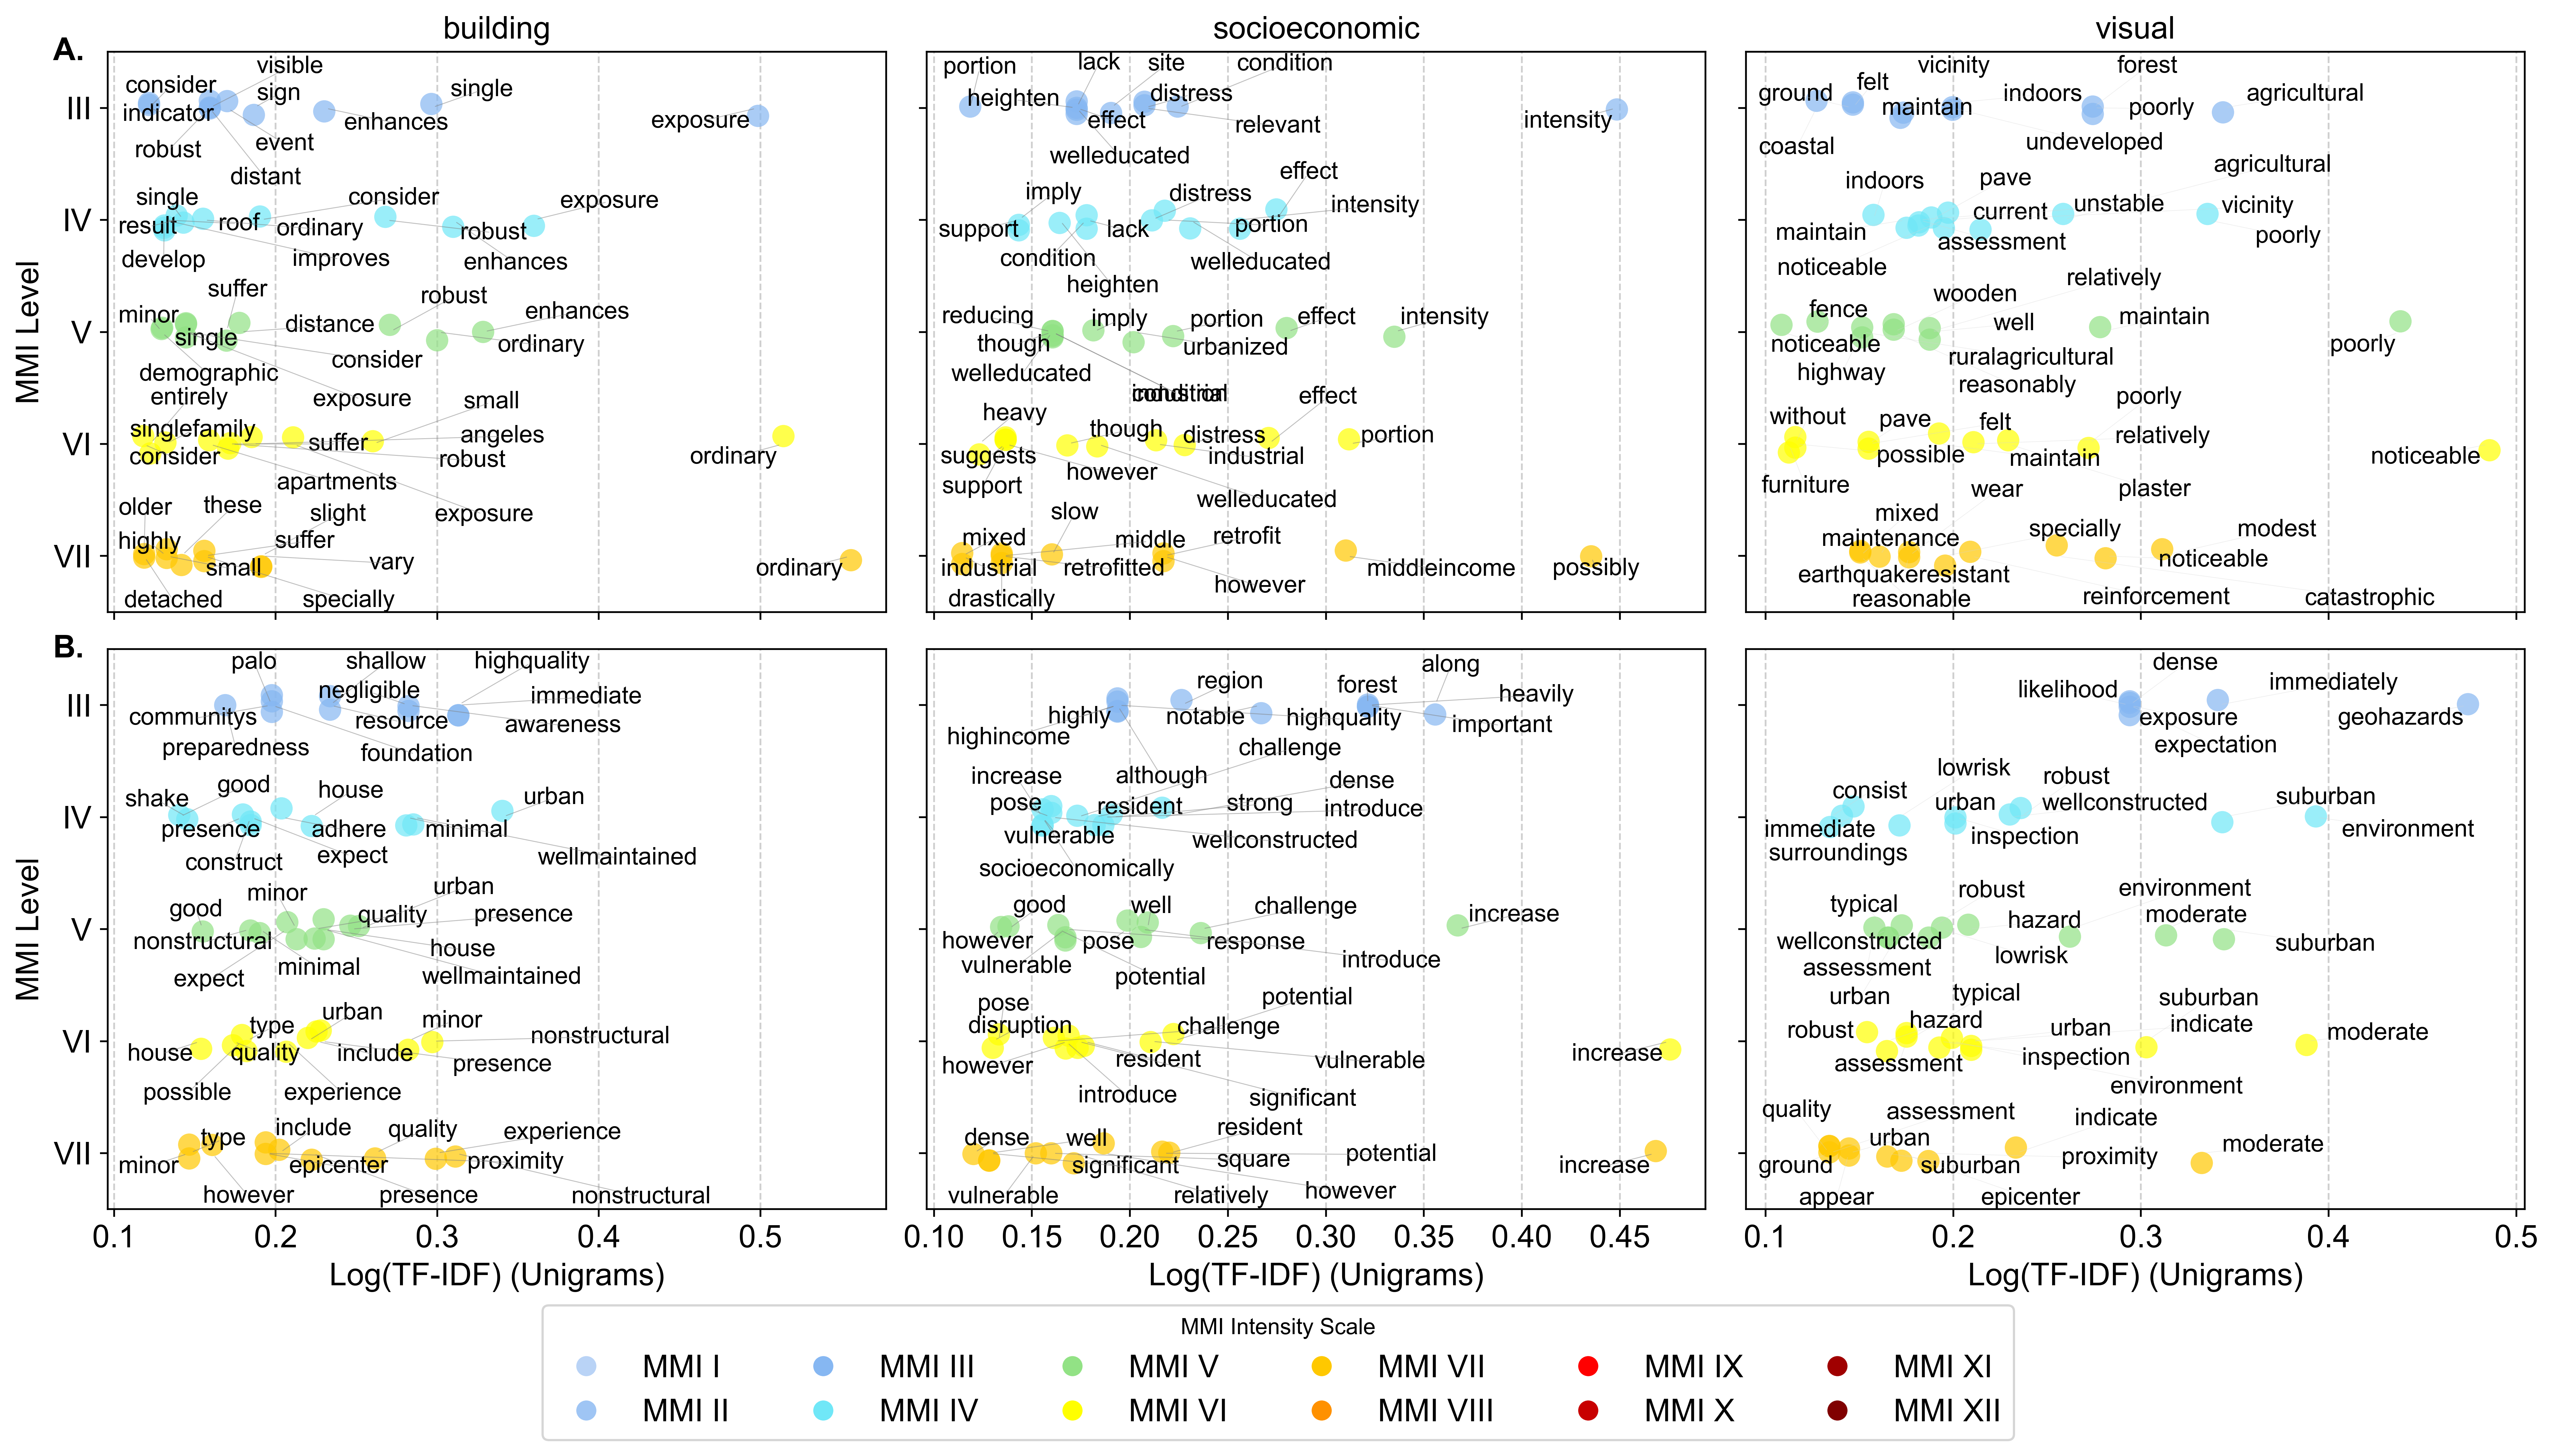

In [22]:
def plot_distinctive_mmi_ngrams(
    df: pd.DataFrame,
    mmi_c: str = 'MMI_predicted',
    txt_c: str = 'clean_reasoning',
    top_n: int = 10,
    top_n_mmi: int = 5,
    font_size: int = 10,
    mode: str = 'unigram', # or 'bigram'
    ax=None,
    add_title: bool = True,
    adjust_text_params: dict = None,
    remove_words: list = None
):
    """
    Updated function allowing removal of specified words from plots.
    """

    remove_words = set(remove_words) if remove_words else set()

    if top_n_mmi is not None and top_n_mmi > 0:
        mmi_counts = df[mmi_c].value_counts()
        actual_top_n_mmi = min(top_n_mmi, len(mmi_counts))
        top_mmi_values = mmi_counts.nlargest(actual_top_n_mmi).index.tolist()
        df_filtered = df[df[mmi_c].isin(top_mmi_values)].copy()
    else:
        df_filtered = df.copy()

    if df_filtered.empty:
        print("No data to plot.")
        return None

    rom_map = {'I':1, 'II':2, 'III':3, 'IV':4, 'V':5, 'VI':6, 'VII':7, 'VIII':8, 'IX':9, 'X':10, 'XI':11, 'XII':12}
    mmi_sorted = sorted(df_filtered[mmi_c].unique(), key=lambda x: rom_map.get(str(x).upper(), float('inf')))

    MIN_WORD_LENGTH = 4
    mmi_texts = {}

    for mmi_val in mmi_sorted:
        subset = df_filtered[df_filtered[mmi_c] == mmi_val]
        raw_text = " ".join(subset[txt_c].astype(str))
        tokens = word_tokenize(raw_text.lower())

        if mode == 'unigram':
            tokens = [token for token in tokens if len(token) >= MIN_WORD_LENGTH and token not in remove_words]
            mmi_texts[mmi_val] = " ".join(tokens)
        else:
            tokens = [token for token in tokens if len(token) >= MIN_WORD_LENGTH and token not in remove_words]
            bigrams_list = list(ngrams(tokens, 2))
            bigram_text = " ".join(["_".join(bg) for bg in bigrams_list])
            mmi_texts[mmi_val] = bigram_text

    corpus = [mmi_texts[mmi] for mmi in mmi_sorted]
    mmi_labels = list(mmi_sorted)

    tfidf_vectorizer = TfidfVectorizer(max_features=2000, min_df=1, max_df=0.8)
    tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    data_points = []

    for i, mmi in enumerate(mmi_labels):
        tfidf_scores = tfidf_matrix[i].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-top_n:][::-1]

        for idx in top_indices:
            term = feature_names[idx]
            if term in remove_words:
                continue
            score = tfidf_scores[idx]

            if mode == 'bigram' and '_' in term:
                term = term.replace('_', ' ')

            if score > 0:
                data_points.append({
                    'MMI': mmi,
                    'Text': term,
                    'Score': score,
                    'LogScore': np.log1p(score)
                })

    if not data_points:
        print("No distinctive n-grams found after removing custom words.")
        return None

    plot_df = pd.DataFrame(data_points)
    plot_df['MMI'] = pd.Categorical(plot_df['MMI'], categories=mmi_sorted, ordered=True)
    plot_df = plot_df.sort_values(by=['MMI', 'Score'], ascending=[True, False])

    if ax is None:
        fig_height = max(8, len(mmi_sorted) * 1.8)
        fig, ax = plt.subplots(figsize=(8, fig_height))

    for mmi_val_iter in mmi_sorted:
        subset = plot_df[plot_df['MMI'] == mmi_val_iter]
        if subset.empty:
            continue
        color = mmi_colors.get(str(mmi_val_iter), '#CCCCCC')
        sns.stripplot(data=subset, x='LogScore', y='MMI', s=10, alpha=0.7, jitter=0.1, color=color, ax=ax, order=mmi_sorted)

    texts = []
    for _, row in plot_df.iterrows():
        mmi_idx = mmi_sorted.index(row['MMI'])
        text_obj = ax.text(row['LogScore'], mmi_idx, row['Text'],
                          fontsize=font_size, color='black',
                          horizontalalignment='center', verticalalignment='center')
        texts.append(text_obj)

    default_adjust_params = {'arrowprops': dict(arrowstyle='-', color='darkgray', lw=0.5, alpha=0.6), 
                            'expand_points': (1.2, 1.2), 
                            'expand_text': (1.4, 1.6), 
                            'force_text': (0.5, 0.7), 
                            'force_points': (0.1, 0.2), 
                            'ha': 'center', 
                            'va': 'center', 
                            'only_move': {'points':'y', 'text':'xy'}, 
                            'lim': 500}

    current_adjust_params = default_adjust_params.copy()
    if adjust_text_params:
        current_adjust_params.update(adjust_text_params)

    if texts:
        adjust_text(texts, ax=ax, **current_adjust_params)

    ax.set_yticklabels(mmi_sorted)
    ax.set_xlabel(f"Log(TF-IDF) ({'Bigrams' if mode=='bigram' else 'Unigrams'})")

    if add_title:
        ax.set_title(f"{txt_c.split('_')[0]}")

    ax.grid(axis='x', linestyle='--', alpha=0.6)

    return plot_df


def plot_all_sources_combined(
    df1: pd.DataFrame, 
    df2: pd.DataFrame,
    sources: list = ['building_clean', 'socioeconomic_clean', 'visual_clean'],
    mmi_c: str = 'MMI_predicted',
    top_n: int = 11,
    top_n_mmi: int = 5,
    font_size: int = 10.5,
    mode: str = 'unigram',
    figsize: tuple = (16, 10),
    custom_words: list = None,
    adjust_text_params_override: dict = None
):
    """
    Create a single figure with six plots arranged in a 2x3 grid:
    - Row A: Three plots from df1 (first dataset)
    - Row B: Three plots from df2 (second dataset)
    With shared column titles and x-axis labels only at the bottom
    """
    num_sources = len(sources)
    fig, axes = plt.subplots(2, num_sources, figsize=figsize, sharex='col', sharey='row')
    
    results = []
    
    # Source-specific parameters for text adjustment
    source_specific_base_params = [
        { # Source 1 (building_clean)
            'expand_text': (1.4, 1.7),
            'force_text': (0.6, 0.8),
            'arrowprops': dict(arrowstyle='-', color='gray', lw=0.4, alpha=0.5)
        },
        { # Source 2 (socioeconomic_clean)
            'expand_text': (1.5, 1.8),
            'force_text': (0.7, 0.9),
            'arrowprops': dict(arrowstyle='-', color='gray', lw=0.4, alpha=0.5)
        },
        { # Source 3 (visual_clean)
            'expand_points': (1.3, 1.3),
            'expand_text': (1.8, 2.2),
            'force_text': (0.9, 1.2),
            'force_points': (0.3, 0.5),
            'arrowprops': dict(arrowstyle='-', color='lightgray', lw=0.3, alpha=0.35)
        }
    ]
    
    # Process both dataframes
    for row, df in enumerate([df1, df2]):
        row_results = []
        
        for col, source in enumerate(sources):
            # Determine if this is the first column (for y-axis label)
            add_y_label = (col == 0)
            
            # Only add title for the first row
            add_title = (row == 0)
            
            # Current axis
            ax = axes[row, col]
            
            # Determine the text adjustment parameters for the current source
            current_plot_adjust_params = {}
            if adjust_text_params_override:  # If a global override is provided
                current_plot_adjust_params = adjust_text_params_override
            elif col < len(source_specific_base_params):
                current_plot_adjust_params = source_specific_base_params[col]
            
            # Plot the data for each dataset independently
            plot_df = plot_distinctive_mmi_ngrams(
                df=df,
                mmi_c=mmi_c,
                txt_c=source,
                top_n=top_n,
                top_n_mmi=top_n_mmi,  # Use top_n_mmi for each dataset
                font_size=font_size,
                mode=mode,
                ax=ax,
                add_title=add_title,  # Only add title for first row
                remove_words=custom_words,
                adjust_text_params=current_plot_adjust_params
            )
            
            # Only show y-axis label for the first column (but keep "MMI Level" for both rows)
            if not add_y_label:
                ax.set_ylabel("")
            else:
                # Always show "MMI Level" label for the first column of both rows
                ax.set_ylabel("MMI Level")
            
            # Only show x-axis label for the bottom row
            if row == 0:
                ax.set_xlabel("")
            
            # Add row labels (A. and B.)
            if col == 0:
                row_label = f"{chr(65+row)}."  # A. or B.
                ax.text(-0.05, 1.0, row_label, 
                         transform=ax.transAxes, fontsize=14, 
                         fontweight='bold', va='center', ha='center')
            
            row_results.append(plot_df)
        
        results.append(row_results)
    
    # Create legend items for all MMI levels
    all_mmi_levels = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']
    legend_elements = []
    
    for level in all_mmi_levels:
        color = mmi_colors.get(level, '#CCCCCC')
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                   markersize=10, label=f'MMI {level}')
        )
    
    fig.legend(
        handles=legend_elements,
        title="MMI Intensity Scale",
        loc='upper center',
        bbox_to_anchor=(0.5, 0.15),
        ncol=6
    )
    
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.2, top=0.92)
    
    return fig, axes, results

# Define custom words to exclude
custom_words = ['specific', 'ageles', 'los', 'ridgecrest', 'adherence', 'hospital', 'warehouse', 'palo'
                'specific', 'green', 'rather', 'specific', 'ageles', 'los', 'ridgecrest', 'adherence', 'meter', 'alto', 'still',
                'hospital', 'warehouse', 'specific', 'green', 'rather', 'this', 'california']

# Create the combined figure with both datasets
fig, axes, results = plot_all_sources_combined(
    df1=df1,  # First dataset for row A
    df2=df2,  # Second dataset for row B
    sources=['building_clean', 'socioeconomic_clean', 'visual_clean'],
    mmi_c='MMI_predicted',
    top_n=10,
    top_n_mmi=5,  # Display top 5 MMI levels for each dataset independently
    font_size=10.8,
    mode='unigram',
    custom_words=custom_words
)

fig.savefig('text.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()